In [1]:
# =========================================
# Optimized Plan 2: Behavior Churn Prediction Based on RFM Features
# Data file: E-commerce.csv
# Workflow:
# 1. Construct RFM features
# 2. Define churn label using the quantile of Recency
# 3. Note: once Recency is used to define the label, it must NOT be used as a model feature
# 4. Build Logistic Regression and Random Forest models
# 5. Output evaluation results and feature importance
# =========================================

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [3]:
# =========================
# 1. Load data
# =========================
file_path = "E-commerce.csv"  
df = pd.read_csv(file_path)

print("=" * 60)
print("1. Overview of Raw Data")
print("=" * 60)
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn list:")
print(df.columns.tolist())

1. Overview of Raw Data
Dataset shape: (2000, 17)

First 5 rows:
  order_id customer_id  age product_id   country signup_date  \
0  ORD5000    CUST1000   39    PROD200    Canada  01/07/2021   
1  ORD5001    CUST1001   61    PROD201       USA  10/19/2020   
2  ORD5002    CUST1002   26    PROD202  Pakistan  06/10/2023   
3  ORD5003    CUST1003   54    PROD203     India   7/30/2023   
4  ORD5004    CUST1004   50    PROD204     India  12/09/2020   

  last_purchase_date  cancellations_count subscription_status  order_date  \
0          2/21/2023                    0              active   8/20/2024   
1         12/08/2021                    0              active   7/17/2025   
2         09/04/2023                    3           cancelled  03/12/2025   
3          2/20/2024                    4              paused   9/19/2024   
4          9/14/2024                    0              active  08/08/2024   

   unit_price  quantity  purchase_frequency preferred_category  product_name  \
0      

In [4]:
# =========================
# 2. Process date columns
# =========================
date_cols = ["signup_date", "last_purchase_date", "order_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print("\n" + "=" * 60)
print("2. Missing Values in Date Columns")
print("=" * 60)
print(df[date_cols].isnull().sum())


2. Missing Values in Date Columns
signup_date           0
last_purchase_date    0
order_date            0
dtype: int64


In [5]:
# =========================
# 3. Construct RFM features
# =========================
# Monetary = unit_price * quantity
df["monetary"] = df["unit_price"] * df["quantity"]

# Frequency = use existing field purchase_frequency
df["frequency"] = df["purchase_frequency"]

# Snapshot date: maximum order date + 1 day
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# Recency = days since last purchase
df["recency"] = (snapshot_date - df["last_purchase_date"]).dt.days

# Customer tenure = days since signup
df["customer_tenure_days"] = (snapshot_date - df["signup_date"]).dt.days

# Handle abnormal values
df["recency"] = df["recency"].clip(lower=0)
df["customer_tenure_days"] = df["customer_tenure_days"].clip(lower=0)

print("\n" + "=" * 60)
print("3. Preview of RFM Variables")
print("=" * 60)
print(df[[
    "customer_id", "recency", "frequency", "monetary",
    "cancellations_count", "customer_tenure_days"
]].head())


3. Preview of RFM Variables
  customer_id  recency  frequency  monetary  cancellations_count  \
0    CUST1000      912         37    391.05                    0   
1    CUST1001     1352         35    512.16                    0   
2    CUST1002      717         44   1208.28                    3   
3    CUST1003      548          1    338.64                    4   
4    CUST1004      341         35    438.62                    0   

   customer_tenure_days  
0                  1687  
1                  1767  
2                   803  
3                   753  
4                  1716  


In [6]:
# =========================
# 4. Create churn label
# =========================
# Define high churn risk using the 75th percentile of recency
threshold = df["recency"].quantile(0.75)
df["churn_label"] = (df["recency"] > threshold).astype(int)

print("\n" + "=" * 60)
print("4. Churn Label Definition")
print("=" * 60)
print(f"75th percentile threshold of Recency: {threshold:.2f}")
print("\nLabel distribution:")
print(df["churn_label"].value_counts())
print("\nLabel ratio:")
print(df["churn_label"].value_counts(normalize=True))


4. Churn Label Definition
75th percentile threshold of Recency: 907.00

Label distribution:
churn_label
0    1501
1     499
Name: count, dtype: int64

Label ratio:
churn_label
0    0.7505
1    0.2495
Name: proportion, dtype: float64


In [7]:
# =========================
# 5. Select features
# Note: recency must not be included in features,
# otherwise it causes target leakage
# =========================
feature_cols = [
    "frequency",
    "monetary",
    "cancellations_count",
    "customer_tenure_days",
    "age",
    "quantity",
    "unit_price",
    "country",
    "preferred_category",
    "category",
    "gender"
]

# Keep only existing columns to avoid errors
feature_cols = [col for col in feature_cols if col in df.columns]

X = df[feature_cols].copy()
y = df["churn_label"].copy()

numeric_features = [col for col in [
    "frequency",
    "monetary",
    "cancellations_count",
    "customer_tenure_days",
    "age",
    "quantity",
    "unit_price"
] if col in X.columns]

categorical_features = [col for col in [
    "country",
    "preferred_category",
    "category",
    "gender"
] if col in X.columns]

print("\n" + "=" * 60)
print("5. Modeling Features")
print("=" * 60)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


5. Modeling Features
Numeric features: ['frequency', 'monetary', 'cancellations_count', 'customer_tenure_days', 'age', 'quantity', 'unit_price']
Categorical features: ['country', 'preferred_category', 'category', 'gender']


In [8]:
# =========================
# 6. Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Compute sample weights on the training set to handle class imbalance
weights = compute_sample_weight(class_weight="balanced", y=y_train)

print("\n" + "=" * 60)
print("6. Dataset Split")
print("=" * 60)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining label distribution:")
print(y_train.value_counts())
print("\nSample weight summary:")
print(pd.Series(weights).describe())


6. Dataset Split
Training set shape: (1600, 11)
Test set shape: (400, 11)

Training label distribution:
churn_label
0    1201
1     399
Name: count, dtype: int64

Sample weight summary:
count    1600.000000
mean        1.000000
std         0.579458
min         0.666112
25%         0.666112
50%         0.666112
75%         0.666112
max         2.005013
dtype: float64


In [9]:
# =========================
# 7. Preprocessing
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
# =========================
# 8. Define evaluation function
# =========================
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name="Model",
    sample_weight=None,
    fit_weight_param_name="classifier__sample_weight"
):
    fit_kwargs = {}
    if sample_weight is not None:
        fit_kwargs[fit_weight_param_name] = sample_weight

    model.fit(X_train, y_train, **fit_kwargs)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("\n" + "=" * 60)
    print(f"{model_name} Evaluation Results")
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model, y_pred, y_prob

In [11]:
# =========================
# 9. Model 1: Logistic Regression
# =========================
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model, y_pred_log, y_prob_log = evaluate_model(
    log_model, X_train, X_test, y_train, y_test, model_name="Logistic Regression"
)


Logistic Regression Evaluation Results
Accuracy : 0.6700
Precision: 0.4059
Recall   : 0.6900
F1-score : 0.5111
ROC-AUC  : 0.7579

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75       300
           1       0.41      0.69      0.51       100

    accuracy                           0.67       400
   macro avg       0.64      0.68      0.63       400
weighted avg       0.75      0.67      0.69       400

Confusion matrix:
[[199 101]
 [ 31  69]]


In [12]:
# =========================
# 10. Model 2: Random Forest
# =========================
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model, y_pred_rf, y_prob_rf = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, model_name="Random Forest"
)


Random Forest Evaluation Results
Accuracy : 0.6625
Precision: 0.3977
Recall   : 0.6800
F1-score : 0.5018
ROC-AUC  : 0.7227

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.66      0.74       300
           1       0.40      0.68      0.50       100

    accuracy                           0.66       400
   macro avg       0.63      0.67      0.62       400
weighted avg       0.74      0.66      0.68       400

Confusion matrix:
[[197 103]
 [ 32  68]]


<Figure size 800x600 with 0 Axes>

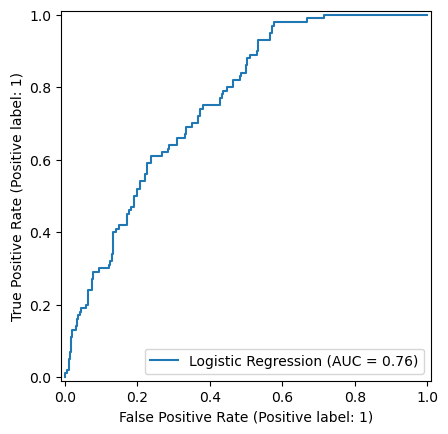

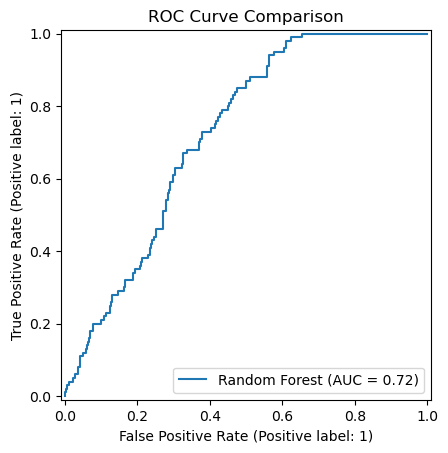

In [13]:
# =========================
# 11. ROC curve
# =========================
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.show()


12. Random Forest Feature Importance (Top 20)
                           feature  importance
3             customer_tenure_days    0.507717
6                       unit_price    0.081732
1                         monetary    0.081254
0                        frequency    0.065108
4                              age    0.060736
5                         quantity    0.031753
2              cancellations_count    0.031643
23                   gender_Female    0.011546
24                     gender_Male    0.009568
16         preferred_category_Home    0.009095
19               category_Clothing    0.008001
20            category_Electronics    0.007961
15  preferred_category_Electronics    0.007920
14     preferred_category_Clothing    0.007879
11                      country_UK    0.007859
10                country_Pakistan    0.007622
8                  country_Germany    0.007202
13       preferred_category_Beauty    0.006843
7                   country_Canada    0.006617
21           

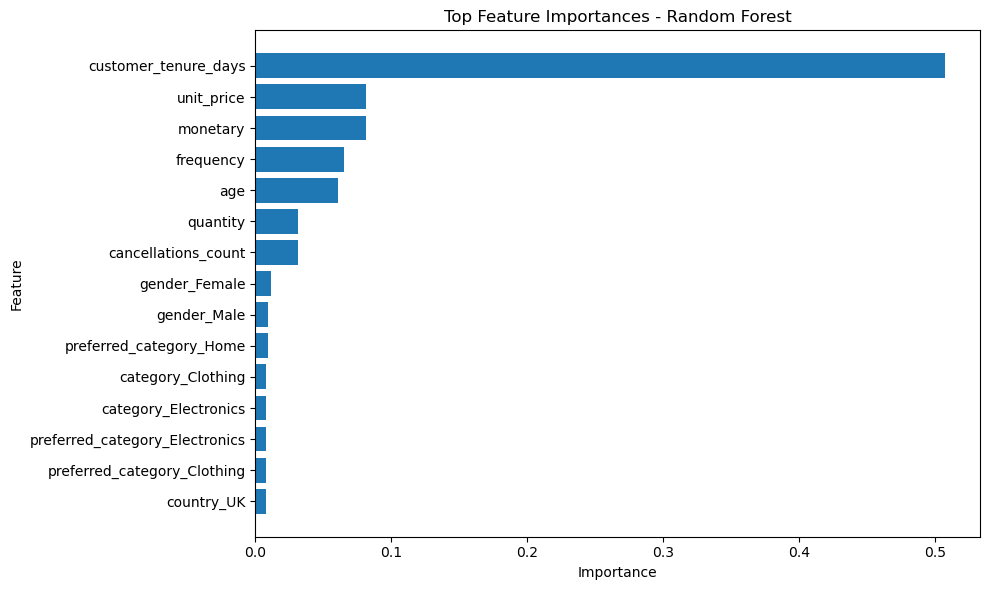

In [14]:
# =========================
# 12. Random Forest feature importance
# =========================
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = []
if len(categorical_features) > 0:
    cat_feature_names = list(ohe.get_feature_names_out(categorical_features))

all_feature_names = numeric_features + cat_feature_names
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n" + "=" * 60)
print("12. Random Forest Feature Importance (Top 20)")
print("=" * 60)
print(feature_importance_df.head(20))


# Visualize feature importance
top_n = min(15, len(feature_importance_df))
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [15]:
# =========================
# 13. Output test set predictions
# =========================
result_df = X_test.copy()
result_df["true_label"] = y_test.values
result_df["pred_label_log"] = y_pred_log
result_df["pred_prob_log"] = y_prob_log
result_df["pred_label_rf"] = y_pred_rf
result_df["pred_prob_rf"] = y_prob_rf

print("\n" + "=" * 60)
print("13. Preview of Test Set Predictions")
print("=" * 60)
print(result_df.head())


13. Preview of Test Set Predictions
      frequency  monetary  cancellations_count  customer_tenure_days  age  \
177          34    932.76                    4                  1736   21   
851          31   1146.75                    2                   853   38   
844          34    402.30                    2                   807   29   
1604         24    368.24                    4                  1405   20   
48           35    599.52                    5                   864   48   

      quantity  unit_price   country preferred_category     category  gender  \
177          9      103.64    Canada             Sports       Sports  Female   
851          1     1146.75   Germany             Sports       Sports  Female   
844          3      134.10        UK             Beauty     Clothing   Other   
1604         8       46.03   Germany           Clothing       Sports  Female   
48           4      149.88  Pakistan             Sports  Electronics    Male   

      true_label  p

In [16]:
# =========================
# 14. Output high-risk customers
# =========================
# Sort by Random Forest predicted probability
high_risk_customers = result_df.sort_values("pred_prob_rf", ascending=False).head(20)

print("\n" + "=" * 60)
print("14. Top 20 High-Risk Customers")
print("=" * 60)
print(high_risk_customers)


14. Top 20 High-Risk Customers
      frequency  monetary  cancellations_count  customer_tenure_days  age  \
1332         36    517.30                    4                  1712   49   
1274          1   1147.65                    0                  1605   60   
235          47    641.68                    0                  1794   22   
991           8    437.26                    1                  1652   53   
1408         16   1533.56                    3                  1672   33   
927          16   1631.00                    3                  1788   54   
311          25   1597.28                    3                  1797   31   
193          26   1229.97                    5                  1468   28   
866          30    813.33                    4                  1784   47   
663          10   1671.12                    1                  1824   40   
747          23    842.28                    0                  1530   45   
151          40   1254.16                   

In [17]:
# =========================
# 15. Display results
# =========================
print("\n" + "=" * 60)
print("15. Results Preview")
print("=" * 60)

# 1) Feature importance
if "feature_importance_df" in locals() or "feature_importance_df" in globals():
    print("\n[1] Random Forest Feature Importance (Top 20)")
    print(feature_importance_df.head(20).to_string(index=False))
else:
    print("\n[1] feature_importance_df is not available.")
    print("Please make sure the feature importance section has been run successfully.")

# 2) Test prediction results
if "result_df" in locals() or "result_df" in globals():
    print("\n[2] Test Prediction Results Preview")
    print(result_df.head(10).to_string())
else:
    print("\n[2] result_df is not available.")
    print("Please make sure the prediction result section has been run successfully.")

# 3) High-risk customers
if "high_risk_customers" in locals() or "high_risk_customers" in globals():
    print("\n[3] Top 20 High-Risk Customers")
    print(high_risk_customers.head(20).to_string())
else:
    print("\n[3] high_risk_customers is not available.")
    print("Please make sure the high-risk customer section has been run successfully.")

print("\n" + "=" * 60)
print("Display completed.")
print("=" * 60)


15. Results Preview

[1] Random Forest Feature Importance (Top 20)
                       feature  importance
          customer_tenure_days    0.507717
                    unit_price    0.081732
                      monetary    0.081254
                     frequency    0.065108
                           age    0.060736
                      quantity    0.031753
           cancellations_count    0.031643
                 gender_Female    0.011546
                   gender_Male    0.009568
       preferred_category_Home    0.009095
             category_Clothing    0.008001
          category_Electronics    0.007961
preferred_category_Electronics    0.007920
   preferred_category_Clothing    0.007879
                    country_UK    0.007859
              country_Pakistan    0.007622
               country_Germany    0.007202
     preferred_category_Beauty    0.006843
                country_Canada    0.006617
                 category_Home    0.006275

[2] Test Prediction Results 

Supplemental Modelling: XGBoost


XGBoost (weighted) Evaluation Results
Accuracy : 0.6400
Precision: 0.3358
Recall   : 0.4500
F1-score : 0.3846
ROC-AUC  : 0.6863

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.70      0.75       300
           1       0.34      0.45      0.38       100

    accuracy                           0.64       400
   macro avg       0.56      0.58      0.57       400
weighted avg       0.68      0.64      0.66       400

Confusion matrix:
[[211  89]
 [ 55  45]]


<Figure size 800x600 with 0 Axes>

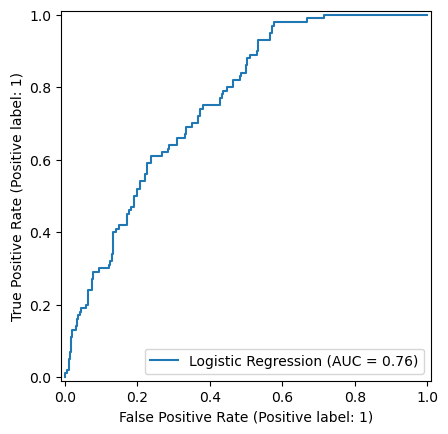

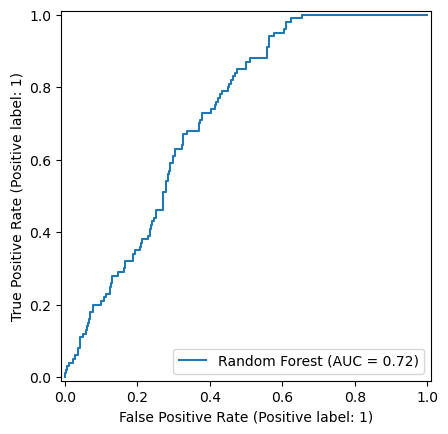

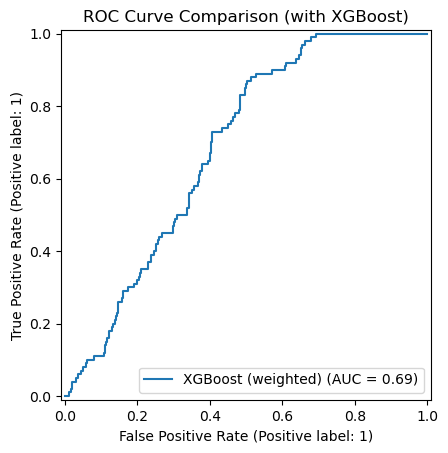


XGBoost Feature Importance (Top 20)
                        feature  importance
3          customer_tenure_days    0.097900
25                 gender_Other    0.055253
20         category_Electronics    0.046003
11                   country_UK    0.042110
14  preferred_category_Clothing    0.039864
4                           age    0.039312
1                      monetary    0.037601
6                    unit_price    0.037525
8               country_Germany    0.036985
0                     frequency    0.036891
10             country_Pakistan    0.036481
2           cancellations_count    0.035600
19            category_Clothing    0.034782
7                country_Canada    0.034468
16      preferred_category_Home    0.034445
18              category_Beauty    0.034111
13    preferred_category_Beauty    0.034007
9                 country_India    0.033462
22              category_Sports    0.033462
17    preferred_category_Sports    0.033247


In [18]:
# =========================
# Supplemental Analysis - Model 3: XGBoost
# =========================
# Use sample_weight=weights to handle class imbalance
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

xgb_model, y_pred_xgb, y_prob_xgb = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name="XGBoost (weighted)",
    sample_weight=weights
)

# Plot ROC including XGBoost for direct comparison
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost (weighted)")
plt.title("ROC Curve Comparison (with XGBoost)")
plt.show()

# XGBoost feature importance
ohe_xgb = xgb_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names_xgb = []
if len(categorical_features) > 0:
    cat_feature_names_xgb = list(ohe_xgb.get_feature_names_out(categorical_features))

all_feature_names_xgb = numeric_features + cat_feature_names_xgb
xgb_importances = xgb_model.named_steps["classifier"].feature_importances_

xgb_feature_importance_df = pd.DataFrame({
    "feature": all_feature_names_xgb,
    "importance": xgb_importances
}).sort_values("importance", ascending=False)

print("\n" + "=" * 60)
print("XGBoost Feature Importance (Top 20)")
print("=" * 60)
print(xgb_feature_importance_df.head(20))


Top 20 High-Risk Customers by XGBoost
      frequency  monetary  cancellations_count  customer_tenure_days  age  \
1274          1   1147.65                    0                  1605   60   
991           8    437.26                    1                  1652   53   
512          23    108.12                    0                  1502   34   
1070         24    361.27                    3                  1662   63   
927          16   1631.00                    3                  1788   54   
1953         34    901.84                    0                  1707   60   
311          25   1597.28                    3                  1797   31   
193          26   1229.97                    5                  1468   28   
235          47    641.68                    0                  1794   22   
1698         41    400.98                    4                  1795   62   
17           18   1267.44                    0                  1437   22   
74           27    266.16            

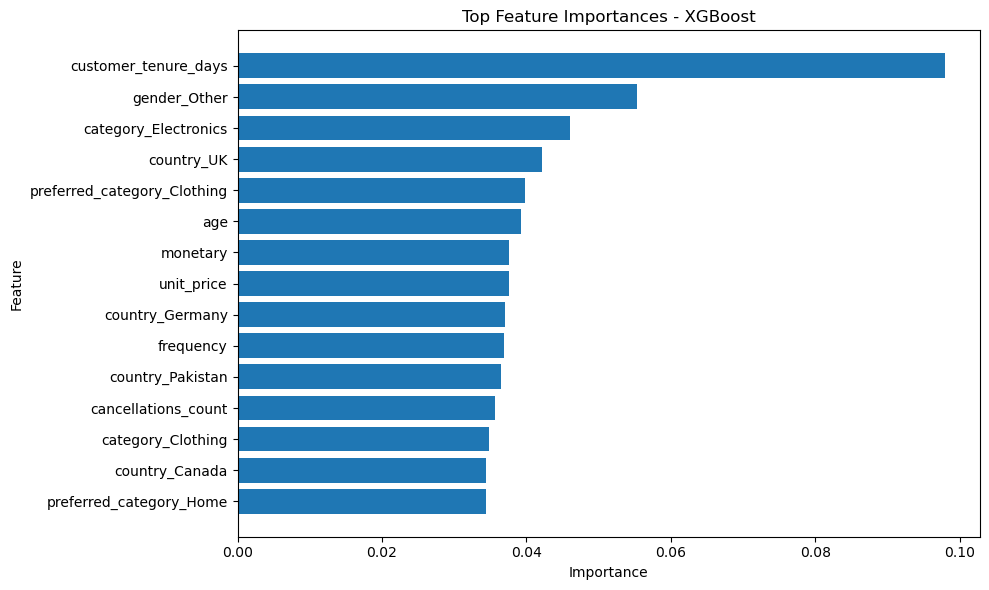

In [19]:
# =========================
# Supplemental Output: XGBoost predictions
# =========================
result_df_xgb = X_test.copy()
result_df_xgb["true_label"] = y_test.values
result_df_xgb["pred_label_xgb"] = y_pred_xgb
result_df_xgb["pred_prob_xgb"] = y_prob_xgb

high_risk_customers_xgb = result_df_xgb.sort_values("pred_prob_xgb", ascending=False).head(20)

print("\n" + "=" * 60)
print("Top 20 High-Risk Customers by XGBoost")
print("=" * 60)
print(high_risk_customers_xgb)

plt.figure(figsize=(10, 6))
top_n_xgb = min(15, len(xgb_feature_importance_df))
top_features_xgb = xgb_feature_importance_df.head(top_n_xgb).sort_values("importance")
plt.barh(top_features_xgb["feature"], top_features_xgb["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances - XGBoost")
plt.tight_layout()
plt.show()